# Uganda's coffee against the world: a benchmark
**Sources:** USDA Foreign Agricultural Service coffee supply and distribution (PSD), all producing countries, market years to 2025/26; FAOSTAT green coffee area, yield, production and trade, to 2024; IMF world prices; Uganda's Coffee Department.

**How peers are chosen (by rule, not by hand)**
- **World:** every country with at least 1% of world production, 2021–2025 average (USDA).
- **Africa:** every African producer above 100,000 bags a year.
- **Like-for-like groups:** countries are grouped by what they grow, using USDA's robusta and arabica split: *robusta-led* (70% or more robusta), *arabica-led* (30% or less), *mixed* (in between). Comparisons that depend on the type of coffee (yield, price) are made within groups or adjusted for the mix.

**Metrics** follow what USDA and the International Coffee Organization report: production and exports in 60-kg bags, share of world exports, growth, domestic consumption, yield per hectare, export price realisation, and production volatility. Every metric carries the quality of its underlying data.

Each finding is written up in a markdown cell directly after the code and output that produced it.

## Setup

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from coffee import (load_world, load_fx, load_cpi, load_farmgate, load_exports_monthly, load_exports_annual,
                    load_maize_kampala, coffee_year)

# Ink and grey, with blue for robusta and orange for arabica
INK, GREY, LIGHT, GRID = '#1a1a1a', '#6b6b6b', '#b5b3ad', '#e6e4df'
ROB, ARA = '#2b6c9e', '#c4572e'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'medium',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c4', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': GREY, 'ytick.color': GREY, 'axes.labelcolor': GREY,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)
MON = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

from coffee import load_psd, load_fao_production, load_fao_trade, FAO_NAMES, AFRICA, EAST_AFRICA, BAG_KG
psd = load_psd()
fao_p, fao_t = load_fao_production(), load_fao_trade()
world = load_world()
print('USDA market years:', psd['Market_Year'].min(), '–', psd['Market_Year'].max(), '|', psd['Country_Name'].nunique(), 'countries')
print('FAOSTAT years:', fao_p['Year'].min(), '–', fao_p['Year'].max())

USDA market years: 1960 – 2026 | 94 countries
FAOSTAT years: 1961 – 2024


---
## 1. Who are the peers?

In [2]:
RECENT = range(2021, 2026)   # USDA market years 2021/22 – 2025/26
cols = ['Production', 'Arabica Production', 'Robusta Production', 'Exports', 'Domestic Consumption']
rec = psd[psd['Market_Year'].isin(RECENT)].groupby('Country_Name')[cols].mean()
rec = rec[rec['Production'] > 0]
rec['world_production_share'] = 100 * rec['Production'] / rec['Production'].sum()
rec['world_export_share'] = 100 * rec['Exports'] / rec['Exports'].sum()
rec['robusta_share'] = 100 * rec['Robusta Production'] / rec['Production']
rec['consumed_at_home'] = 100 * rec['Domestic Consumption'] / rec['Production']
rec['production_rank'] = rec['Production'].rank(ascending=False).astype(int)
rec['export_rank'] = rec['Exports'].rank(ascending=False).astype(int)
rec['group'] = np.select([rec['robusta_share'] >= 70, rec['robusta_share'] <= 30], ['Robusta-led', 'Arabica-led'], 'Mixed')
rec['africa'] = rec.index.isin(AFRICA)

world_peers = rec[rec['world_production_share'] >= 1].index
africa_peers = rec[rec['africa'] & (rec['Production'] >= 100)].index
peers = rec.loc[sorted(set(world_peers) | set(africa_peers), key=lambda c: -rec.loc[c, 'Production'])].copy()
peers['set'] = np.where(peers.index.isin(world_peers) & peers['africa'], 'World and Africa',
                        np.where(peers.index.isin(world_peers), 'World', 'Africa'))
print(f'{len(world_peers)} world peers, {len(africa_peers)} African peers, {len(peers)} in total')
peers[['set', 'group', 'Production', 'Exports', 'world_production_share', 'world_export_share', 'production_rank', 'export_rank', 'robusta_share', 'consumed_at_home']].round(1)

13 world peers, 11 African peers, 22 in total


Attribute_Description,set,group,Production,Exports,world_production_share,world_export_share,production_rank,export_rank,robusta_share,consumed_at_home
Country_Name,,,,,,,,,,
Brazil,World,Mixed,63100.0,41040.0,36.9,30.2,1,1,35.5,35.2
Vietnam,World,Robusta-led,29626.0,27090.0,17.3,20.0,2,2,96.4,13.5
Colombia,World,Arabica-led,12512.0,12186.4,7.3,9.0,3,3,0.0,17.4
Indonesia,World,Robusta-led,10500.0,7348.4,6.1,5.4,4,4,87.4,45.7
Ethiopia,World and Africa,Arabica-led,9520.0,5753.2,5.6,4.2,5,7,0.0,39.5
Uganda,World and Africa,Robusta-led,6562.0,6290.0,3.8,4.6,6,6,84.4,4.3
India,World,Robusta-led,6123.2,6555.0,3.6,4.8,7,5,73.1,18.8
Honduras,World,Arabica-led,5256.0,4933.6,3.1,3.6,8,8,0.0,6.8
Peru,World,Arabica-led,4094.2,3969.4,2.4,2.9,9,9,0.0,6.6


**Finding:** the rule gives 13 world peers and 11 African peers (22 countries in all, with Ethiopia and Uganda in both sets). **Uganda is the world's 6th-largest producer and 6th-largest exporter**, with about 4.6% of world exports, and **Africa's largest exporter**. Ethiopia produces more but drinks about 40% of its own crop; Uganda consumes only about 4% at home, so almost everything it grows is exported.

Uganda is *robusta-led* (about 84% robusta), alongside Vietnam, Indonesia and India and the West and Central African robusta producers. Its arabica (about 1 million bags) is best compared with the East African arabica producers.

---
## 2. Growth

In [3]:
prod = psd.pivot_table(index='Market_Year', columns='Country_Name', values='Production')
exp_ = psd.pivot_table(index='Market_Year', columns='Country_Name', values='Exports')
growth = pd.DataFrame({
    'production growth, % a year': 100 * ((prod.loc[2021:2025].mean() / prod.loc[2006:2010].mean()) ** (1 / 15) - 1),
    'export growth, % a year': 100 * ((exp_.loc[2021:2025].mean() / exp_.loc[2006:2010].mean()) ** (1 / 15) - 1),
}).loc[peers.index]
growth['group'] = peers['group']
growth.sort_values('production growth, % a year', ascending=False).round(1)

,"production growth, % a year","export growth, % a year",group
Country_Name,,,
China,6.8,3.7,Arabica-led
Uganda,5.0,5.2,Robusta-led
Ethiopia,3.7,4.3,Arabica-led
Vietnam,3.2,3.0,Robusta-led
Nicaragua,2.9,2.7,Arabica-led
Honduras,2.6,2.5,Arabica-led
Tanzania,2.6,2.1,Mixed
Brazil,1.9,2.0,Mixed
India,1.8,3.3,Robusta-led


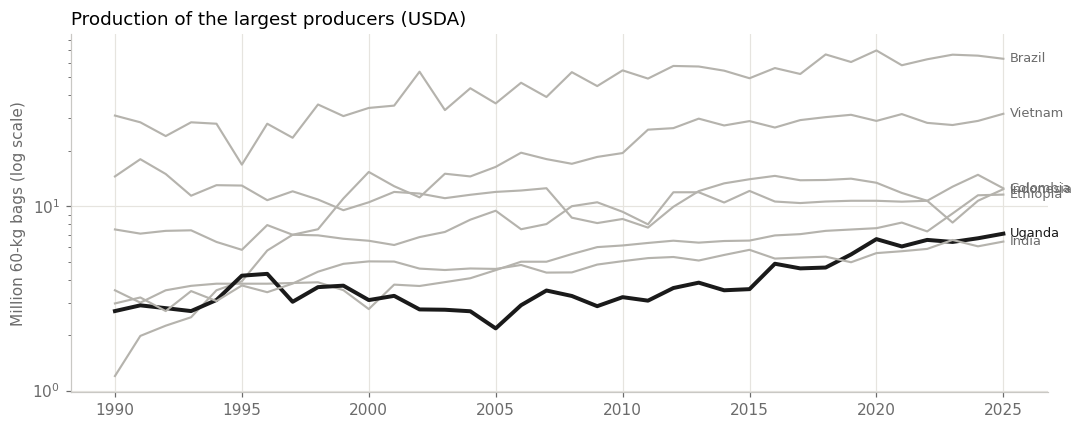

In [4]:
top = ['Brazil', 'Vietnam', 'Colombia', 'Indonesia', 'Ethiopia', 'Uganda', 'India']
fig, ax = plt.subplots(figsize=(10, 4))
for c in top:
    s = prod[c].loc[1990:2025] / 1000
    ax.plot(s.index, s.values, lw=2.6 if c == 'Uganda' else 1.4, color=INK if c == 'Uganda' else LIGHT)
    ax.annotate(c, (s.index[-1], s.values[-1]), xytext=(4, 0), textcoords='offset points', fontsize=8.5,
                color=INK if c == 'Uganda' else GREY, va='center')
ax.set_yscale('log'); ax.set_ylabel('Million 60-kg bags (log scale)')
ax.set_title('Production of the largest producers (USDA)'); plt.tight_layout(); plt.show()

**Finding:** comparing 2021–25 with 2006–10, **Uganda's production grew about 5% a year, the fastest of the ten largest producers** (among all peers only China, from a much smaller base, grew faster). Brazil and Colombia grew about 1.5–2% a year; several West and Central African robusta producers shrank (Côte d'Ivoire, Cameroon, Guinea and Madagascar, by about 4–7% a year). Uganda has moved from being one of many African robusta producers to being in a class of its own on the continent.

---
## 3. Yield: the biggest gap, and the least certain number

In [5]:
def fao_name(c):
    return FAO_NAMES.get(c, c)

rows = []
for c in peers.index:
    q = fao_p[(fao_p['Area'] == fao_name(c)) & fao_p['Year'].between(2020, 2024)]
    area, yld = q[q['Element'] == 'Area harvested'], q[q['Element'] == 'Yield']
    official = (area['Flag'] == 'A').mean() if len(area) else np.nan
    rows.append({'country': c, 'group': peers.loc[c, 'group'], 'yield, kg/ha': yld['Value'].mean(),
                 'area figures official (%)': 100 * official,
                 'data quality': 'official' if official == 1 else ('partly estimated' if official > 0 else 'estimated or imputed')})
yields = pd.DataFrame(rows).set_index('country')
yields.sort_values(['group', 'yield, kg/ha'], ascending=[True, False]).round(0)

,group,"yield, kg/ha",area figures official (%),data quality
country,,,,
China,Arabica-led,3419.0,0.0,estimated or imputed
Honduras,Arabica-led,1178.0,0.0,estimated or imputed
Nicaragua,Arabica-led,1022.0,100.0,official
Rwanda,Arabica-led,1019.0,60.0,partly estimated
Burundi,Arabica-led,932.0,0.0,estimated or imputed
Colombia,Arabica-led,851.0,100.0,official
Peru,Arabica-led,845.0,100.0,official
Ethiopia,Arabica-led,669.0,40.0,partly estimated
Guatemala,Arabica-led,655.0,60.0,partly estimated


**Finding:** among robusta-led producers with official area data, **Vietnam harvests about 2,900 kg of green coffee per hectare; India and Indonesia 600–750**. FAOSTAT puts Uganda at about **560 kg/ha, a gap of roughly five times to Vietnam**.

**But Uganda's yield is the least certain number in this benchmark.** FAOSTAT's harvested area for Uganda is imputed in every year from 2020 to 2024, so its yield is a production figure divided by an estimated area. Uganda's coffee is also largely smallholder and intercropped with bananas and food crops, which makes "area" itself hard to define. The direction of the gap is not in doubt (Vietnam's intensive, irrigated, fertilised monoculture is in a different league), but its size is. A measured yield survey is the single most valuable missing data point for Uganda's coffee sector.

---
## 4. Price: is Uganda paid fairly for what it sells?

In [6]:
w20 = world.loc['2020':'2024'].mean()
rows = []
for c in peers.index:
    t = fao_t[(fao_t['Area'] == fao_name(c))]
    yrs = [f'Y{y}' for y in range(2020, 2025)]
    q = t[t['Element'] == 'Export quantity'][yrs].sum(axis=1)
    v = t[t['Element'] == 'Export value'][yrs].sum(axis=1)
    if not len(q) or q.iloc[0] <= 0:
        continue
    price = float(v.iloc[0] / q.iloc[0])            # 1000 US$ per tonne = US$ per kg
    r = peers.loc[c, 'robusta_share'] / 100
    reference = r * w20['robusta_usd_kg'] + (1 - r) * w20['arabica_usd_kg']
    rows.append({'country': c, 'group': peers.loc[c, 'group'], 'export price, US$/kg': price,
                 'mix reference, US$/kg': reference, 'price realisation (%)': 100 * price / reference})
prices = pd.DataFrame(rows).set_index('country')
print(f"World reference prices 2020–24: robusta US${w20['robusta_usd_kg']:.2f}/kg, arabica (other milds) US${w20['arabica_usd_kg']:.2f}/kg")
prices.sort_values(['group', 'price realisation (%)'], ascending=[True, False]).round(2)

World reference prices 2020–24: robusta US$2.57/kg, arabica (other milds) US$4.73/kg


,group,"export price, US$/kg","mix reference, US$/kg",price realisation (%)
country,,,,
Kenya,Arabica-led,5.56,4.73,117.65
Mexico,Arabica-led,4.62,4.45,103.79
Colombia,Arabica-led,4.87,4.73,102.97
Guatemala,Arabica-led,4.64,4.65,99.90
Rwanda,Arabica-led,4.63,4.73,97.97
Ethiopia,Arabica-led,4.56,4.73,96.50
Peru,Arabica-led,4.16,4.73,87.97
Nicaragua,Arabica-led,3.80,4.60,82.56
Honduras,Arabica-led,3.87,4.73,81.85


**Reading the table:** each country's average export price (FAOSTAT export value ÷ quantity, 2020–2024) is compared with what its mix of coffee would fetch at world reference prices (its robusta share × the world robusta price, plus its arabica share × the world arabica price). A realisation of 100% means the country is paid exactly the benchmark for its mix.

**Finding:** **Uganda realises about 85% of the reference for its mix**: more than Vietnam (82%) and every West and Central African robusta exporter (68–76%), but less than India (96%) and Indonesia (106%), whose exports include more washed and specialty coffee. Producers further above the reference tend to sell specialty grades, washed coffee or processed products; those below it sell lower grades or face high marketing costs. Unit values are averages across all grades and destinations, so they measure the overall price received, not quality directly.

---
## 5. Stability and home consumption

In [7]:
vol = 100 * np.log(prod.loc[2000:2025].replace(0, np.nan)).diff().std()
stab = pd.DataFrame({'group': peers['group'], 'typical year-to-year production swing (%)': vol.loc[peers.index],
                     'share consumed at home (%)': peers['consumed_at_home']})
stab.sort_values('typical year-to-year production swing (%)').round(1)

,group,typical year-to-year production swing (%),share consumed at home (%)
Country_Name,,,
India,Robusta-led,6.3,18.8
Guatemala,Arabica-led,8.4,22.0
Ethiopia,Arabica-led,8.7,39.5
Vietnam,Robusta-led,12.0,13.5
Congo (Kinshasa),Robusta-led,12.6,52.8
Colombia,Arabica-led,13.1,17.4
Uganda,Robusta-led,13.4,4.3
Mexico,Arabica-led,13.4,79.6
Kenya,Arabica-led,13.6,6.4


**Finding:** Uganda's production swings by about 13% from one year to the next, in the middle of the pack: steadier than Brazil (frost and drought, about 20%) and far steadier than several West African producers (over 30%), but less steady than India or Ethiopia (6–9%).

Uganda consumes only about 4% of its coffee at home, among the lowest of all peers. Ethiopia (about 40%), Brazil (about 35%) and Indonesia (about 45%) have large home markets that absorb surpluses and support local roasting and value addition. For Uganda, a growing domestic market is an untapped buffer.

---
## 6. The data gap: three sources, three numbers

In [8]:
cd = load_exports_annual()
cd.index = [int(i[:4]) for i in cd.index]            # financial year starting July of that year
usda = exp_['Uganda']                                    # market year starting October of that year
tq = fao_t[(fao_t['Area'] == 'Uganda') & (fao_t['Element'] == 'Export quantity')]
fao_bags = pd.Series({y: tq[f'Y{y}'].iloc[0] * 1000 / BAG_KG for y in range(2010, 2025)})   # calendar year
gap = pd.DataFrame({'Coffee Department (Jul–Jun)': cd['total_bags'] / 1e6,
                    'USDA (Oct–Sep)': usda / 1000, 'FAOSTAT (calendar year)': fao_bags / 1e6}).loc[2010:2025]
gap['largest gap (%)'] = 100 * (gap.max(axis=1) / gap.min(axis=1) - 1)
gap.round(2)

,Coffee Department (Jul–Jun),USDA (Oct–Sep),FAOSTAT (calendar year),largest gap (%)
2010,3.15,3.15,2.53,24.58
2011,2.73,3.00,3.10,13.57
2012,3.58,3.58,2.82,27.17
2013,3.50,3.60,3.84,9.65
2014,3.46,3.35,3.53,5.24
2015,3.32,3.30,3.66,10.78
2016,4.61,4.60,3.51,31.21
2017,4.31,4.30,4.78,11.24
2018,4.44,4.45,4.20,5.88
2019,5.36,5.35,4.61,16.17


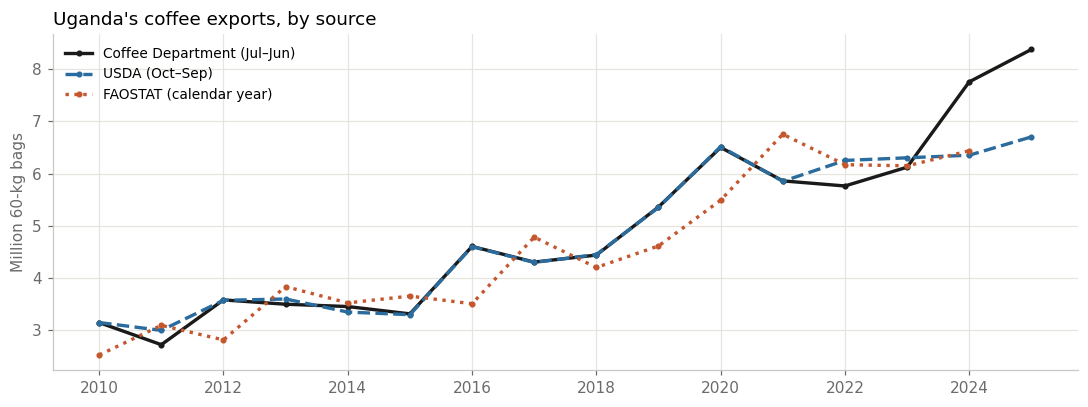

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for c, col, ls in [('Coffee Department (Jul–Jun)', INK, '-'), ('USDA (Oct–Sep)', ROB, '--'), ('FAOSTAT (calendar year)', ARA, ':')]:
    ax.plot(gap.index, gap[c], color=col, lw=2.2, ls=ls, marker='o', ms=3, label=c)
ax.set_ylabel('Million 60-kg bags'); ax.set_title("Uganda's coffee exports, by source"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Finding:** USDA's figures for Uganda matched the Coffee Department's almost exactly until 2021, then diverged. **For 2024/25 the Coffee Department reports 7.75 million bags and USDA 6.35 million (22% less); for 2025/26, 8.37 against 6.70 million (25% less).** FAOSTAT counts calendar years, which splits harvests differently, so it can differ by up to 30% in a single year without disagreeing about the trend; its 2024 figure (6.4 million bags) sits close to USDA's.

Possible reasons include coffee from neighbouring countries (eastern DR Congo, South Sudan) being exported through Uganda, different treatment of stocks, and USDA's practice of building its estimates from production rather than customs records. This matters for any benchmark: on USDA figures, Uganda's growth since 2021 is much smaller than the national figures show. **This report uses USDA for cross-country comparisons, so that every country is measured the same way, and the Coffee Department's figures for Uganda-only analysis.**

---
## Export

In [10]:
from pathlib import Path
out = Path('../data/processed')
bench = peers[['set', 'group', 'Production', 'Exports', 'world_production_share', 'world_export_share', 'production_rank',
               'export_rank', 'robusta_share', 'consumed_at_home']].join(growth.drop(columns='group')).join(
               yields.drop(columns='group')).join(prices.drop(columns='group')).join(stab.drop(columns=['group', 'share consumed at home (%)']))
bench.round(3).to_csv(out / 'benchmark_peers.csv')
gap.round(4).to_csv(out / 'benchmark_uganda_source_gap.csv')
(prod.loc[1990:2025, peers.index] / 1000).round(4).to_csv(out / 'benchmark_production_series.csv')
print('Saved 3 tables to data/processed/')

Saved 3 tables to data/processed/


---
## Summary

- **Uganda is the world's 6th-largest coffee producer and exporter, and Africa's largest exporter**, with about 4% of world exports.
- **It is the fastest-growing of the ten largest producers**, at about 5% a year since 2006–10, while most West and Central African robusta producers have shrunk.
- **Its biggest gap is yield**: perhaps a fifth of Vietnam's per hectare. But Uganda's yield is also the least reliable number in the data, because its harvested area is imputed.
- **It is paid about 85% of the world reference for its mix**: more than Vietnam and the other African robusta exporters, less than India and Indonesia.
- **It drinks almost none of its own coffee** (about 4%), unlike Ethiopia, Brazil or Indonesia.
- **Its export figures differ by source by 22–25% for the last two years.** Cross-country comparisons here use USDA so that all countries are measured alike.

**Caveats:** FAOSTAT yields and areas are imputed for many African producers; export unit values average across grades; USDA figures are estimates built from production, not customs records.